In [1]:
# ==============================================================================
# 1. ENVIRONMENT SETUP & LIBRARIES
# ==============================================================================
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Fix seed for strict reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# ==============================================================================
# 2. DATA LOADING & INSPECTION
# ==============================================================================
TRAIN_PATH = '/kaggle/input/competitions/spaceship-titanic/train.csv'
TEST_PATH = '/kaggle/input/competitions/spaceship-titanic/test.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Training Data Shape : {train_df.shape}")
print(f"Testing Data Shape  : {test_df.shape}")

Training Data Shape : (8693, 14)
Testing Data Shape  : (4277, 13)


In [3]:
train_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
# ==============================================================================
# 3. FEATURE ENGINEERING & SCALING FOR DEEP LEARNING
# ==============================================================================
def preprocess_deep_learning_data(train, test):
    df = pd.concat([train, test], axis=0).reset_index(drop=True)
    
    # --- Group Features ---
    df[['Group_ID', 'Group_Member']] = df['PassengerId'].str.split('_', expand=True)
    df['Group_Size'] = df.groupby('Group_ID')['Group_ID'].transform('count')
    df['Is_Alone'] = (df['Group_Size'] == 1).astype(int)
    
    # --- Cabin Features ---
    df[['Cabin_Deck', 'Cabin_Num', 'Cabin_Side']] = df['Cabin'].str.split('/', expand=True)
    df['Cabin_Num'] = pd.to_numeric(df['Cabin_Num'], errors='coerce')
    df['Cabin_Num'] = df['Cabin_Num'].fillna(df['Cabin_Num'].median())
    
    # --- Spending Features ---
    amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in amenities:
        df[col] = df[col].fillna(0)
        
    df['Total_Spending'] = df[amenities].sum(axis=1)
    df['Zero_Spending'] = (df['Total_Spending'] == 0).astype(int)
    
    # --- Log Transformation for Skewed Spending Features ---
    for col in amenities + ['Total_Spending']:
        df[f'{col}_Log'] = np.log1p(df[col])
        
    # --- Demographic Features ---
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Is_Child'] = (df['Age'] < 13).astype(int)
    
    # --- Categorical Encoding & Imputation ---
    cat_columns = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side']
    for col in cat_columns:
        df[col] = df[col].astype(str).fillna('Missing')
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        
    # --- Drop Unused Columns ---
    drop_cols = ['PassengerId', 'Cabin', 'Name', 'Group_ID', 'Group_Member']
    df.drop(columns=drop_cols, inplace=True)
    
    # --- Split Data back to Train and Test ---
    train_clean = df[df['Transported'].notnull()].copy()
    test_clean = df[df['Transported'].isnull()].copy()
    
    train_clean['Transported'] = train_clean['Transported'].astype(int)
    test_clean.drop(columns=['Transported'], inplace=True)
    
    # Scale Features for Neural Network Convergence
    feature_cols = [c for c in train_clean.columns if c != 'Transported']
    scaler = StandardScaler()
    
    train_clean[feature_cols] = scaler.fit_transform(train_clean[feature_cols])
    test_clean[feature_cols] = scaler.transform(test_clean[feature_cols])
    
    return train_clean, test_clean

train_clean, test_clean = preprocess_deep_learning_data(train_df, test_df)

print("Data Preprocessing & Standard Scaling Completed!")
print(f"Cleaned Train Shape : {train_clean.shape}")
print(f"Cleaned Test Shape  : {test_clean.shape}")

Data Preprocessing & Standard Scaling Completed!
Cleaned Train Shape : (8693, 25)
Cleaned Test Shape  : (4277, 24)


In [5]:
# ==============================================================================
# 4. PYTORCH DATASET & MODEL ARCHITECTURE
# ==============================================================================
class TabularDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1) if y is not None else None
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

class TabularNN(nn.Module):
    def __init__(self, input_dim):
        super(TabularNN, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.network(x)

print("Neural Network Architecture Defined.")

Neural Network Architecture Defined.


In [6]:
# ==============================================================================
# 5. CROSS-VALIDATION MODEL TRAINING
# ==============================================================================
X = train_clean.drop(columns=['Transported']).values
y = train_clean['Transported'].values
X_test = test_clean.values

N_SPLITS = 5
EPOCHS = 80
BATCH_SIZE = 128
LEARNING_RATE = 1e-3

folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds = np.zeros(len(train_clean))
test_preds = np.zeros(len(test_clean))

criterion = nn.BCEWithLogitsLoss()

print("Starting PyTorch Cross-Validation Training...\n")

for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):
    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    
    train_dataset = TabularDataset(X_train, y_train)
    val_dataset = TabularDataset(X_val, y_val)
    test_dataset = TabularDataset(X_test)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model = TabularNN(input_dim=X.shape[1]).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_loss = float('inf')
    best_probs = None
    
    for epoch in range(EPOCHS):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
        # Validation evaluation
        model.eval()
        val_loss = 0.0
        val_preds_list = []
        
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item() * batch_x.size(0)
                probs = torch.sigmoid(outputs)
                val_preds_list.extend(probs.cpu().numpy())
                
        val_loss = val_loss / len(val_dataset)
        scheduler.step(val_loss)
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_probs = np.array(val_preds_list).flatten()
            
    oof_preds[val_idx] = best_probs
    fold_acc = accuracy_score(y_val, (best_probs > 0.5).astype(int))
    print(f"Fold {fold + 1} | Best Loss: {best_loss:.4f} | Val Accuracy: {fold_acc:.5f}")
    
    # Inference on test dataset
    model.eval()
    fold_test_preds = []
    with torch.no_grad():
        for batch_x in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            probs = torch.sigmoid(outputs)
            fold_test_preds.extend(probs.cpu().numpy())
            
    test_preds += np.array(fold_test_preds).flatten() / N_SPLITS

overall_acc = accuracy_score(y, (oof_preds > 0.5).astype(int))
print("\n" + "="*50)
print(f"Overall OOF PyTorch Neural Network Accuracy: {overall_acc:.5f}")
print("="*50)

Starting PyTorch Cross-Validation Training...

Fold 1 | Best Loss: 0.4114 | Val Accuracy: 0.80679
Fold 2 | Best Loss: 0.4344 | Val Accuracy: 0.79068
Fold 3 | Best Loss: 0.4027 | Val Accuracy: 0.81541
Fold 4 | Best Loss: 0.4121 | Val Accuracy: 0.80898
Fold 5 | Best Loss: 0.4334 | Val Accuracy: 0.79287

Overall OOF PyTorch Neural Network Accuracy: 0.80294


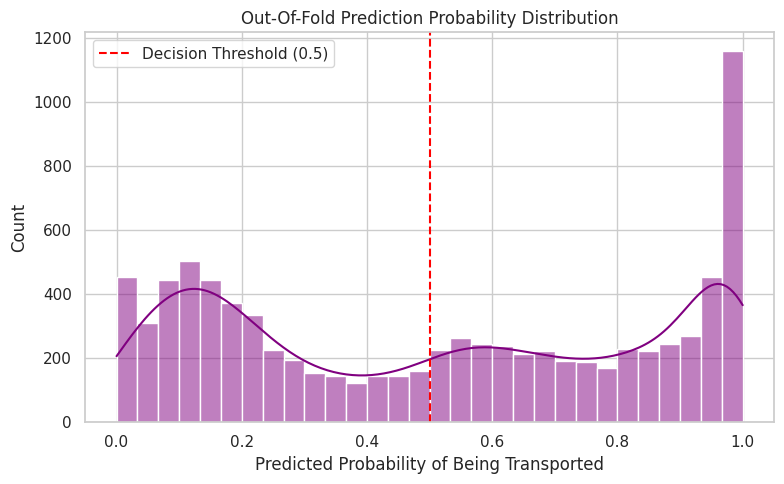

In [7]:
# ==============================================================================
# 6. OUT-OF-FOLD PROBABILITY DISTRIBUTION VISUALIZATION
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.histplot(oof_preds, bins=30, kde=True, color='purple')
plt.axvline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.title('Out-Of-Fold Prediction Probability Distribution')
plt.xlabel('Predicted Probability of Being Transported')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# ==============================================================================
# 7. GENERATE SUBMISSION FILE
# ==============================================================================
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': (test_preds > 0.5)
})

submission.to_csv('submission.csv', index=False)
print("Submission file successfully created and saved as 'submission.csv'!")

# Distribution check
print("\nTarget Class Distribution in Predictions:")
print(submission['Transported'].value_counts(normalize=True))

Submission file successfully created and saved as 'submission.csv'!

Target Class Distribution in Predictions:
Transported
True     0.512976
False    0.487024
Name: proportion, dtype: float64


In [9]:
submission.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
